In this notebook, we walk through the the rediscovery of the circular harmonics (discretized), as the eigenvectors of the representation of $\rho(g)$ of an element $g \in C_{32}$ as a circulant matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def plot_function_on_circle(ax, v, kwargs):
    ax.plot(np.linspace(0,2*np.pi,32),v, **kwargs)
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$f(\theta)$")
    ax.set_xticks([0,np.pi/2,np.pi,3*np.pi/2,2*np.pi])
    ax.set_xticklabels([r"$0$",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3\pi}{2}$",r"$2\pi$"])


We define some arbitrary function on the circle, sampled with 32 equally spaced points

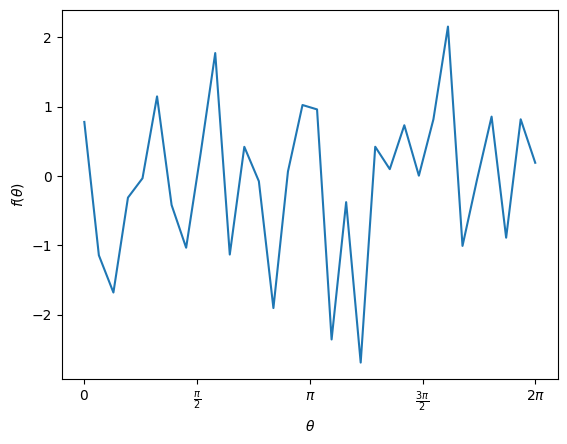

In [2]:
fig, ax = plt.subplots(1)

v = np.random.randn(32)
plot_function_on_circle(ax, v, {})


Define and visualize the circulant matrix.

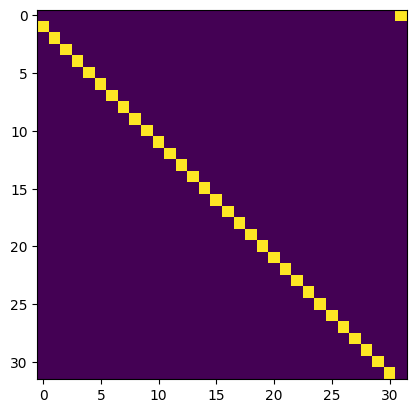

In [3]:
C = np.concatenate([np.eye(32)[:,1:], np.array([1]+31*[0])[:,None]],axis=-1)
plt.imshow(C)

Test if the circulant matrix is actually doing what it is supposed to (shift $\pi/16$ to the right)

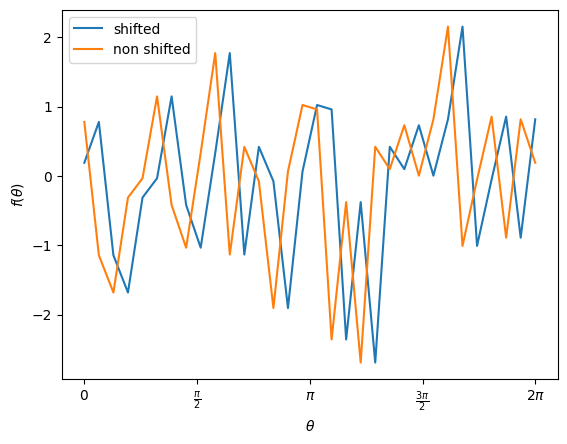

In [4]:
fig, ax = plt.subplots(1)
plot_function_on_circle(ax, C@v,{'label':'shifted'})
plot_function_on_circle(ax, v,{'label':'non shifted'})
plt.legend()

We compute the change of basis to an irreducible representation of $C_{32}$ --- we are solving a diagonalization or eigenvalue problem (check the definition in the slides).

In [5]:
eigvals, eigs = np.linalg.eigh(C)

Eigenvalues (irreducible representations) and eigenvectors (the basis) are sorted in acending order, and we visualize the largest 4

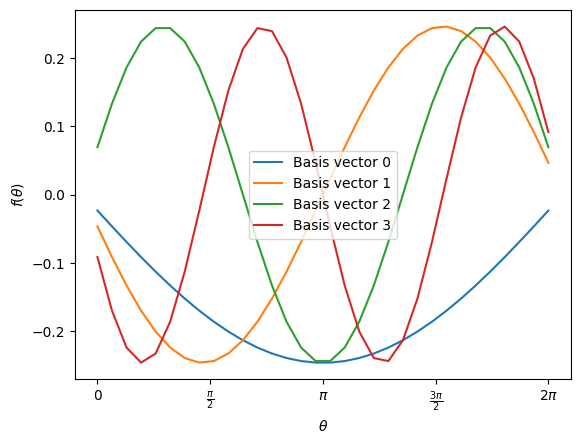

In [6]:
fig, ax = plt.subplots(1)
for i in range(4):
    plot_function_on_circle(ax, eigs[:,-(i+1)], {'label':f"Basis vector {i}"})
plt.legend()

Perform Fourier transform of our arbitrary function $v(\theta)$ -> get Fourier coeffiecients $a$

In [7]:
a = eigs@v

Compare inverse Fourier transform of full and truncated

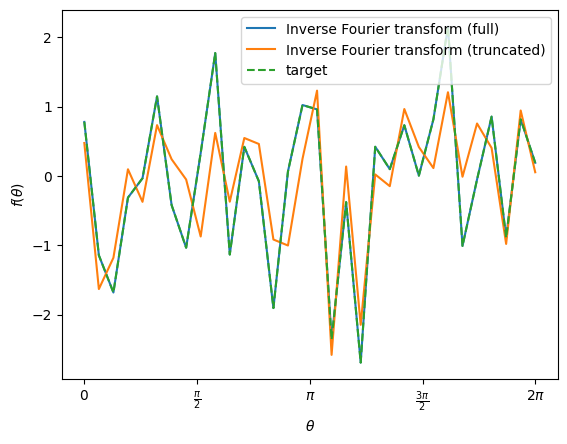

In [8]:
fig, ax = plt.subplots(1)
plot_function_on_circle(ax, eigs.T@a, {'label':f"Inverse Fourier transform (full)"})
plot_function_on_circle(ax, eigs.T[:,:24]@a[:24], {'label':f"Inverse Fourier transform (truncated)"})

plot_function_on_circle(ax, v, {'label':f"target", 'ls':'--'})
plt.legend()


**Exercise:**
Experiment with the number of basis functions you include in the truncated basis. What do you see?

**Exercise:** Remember that the convolution theorem tells you that the convolution is a product in Fourier space -- in other, words, you can convolve two functions by taking the product of their Fourier coefficients and then doing an inverse Fourier transform. Try to define a convolution kernel and using it to convolve your function $v(\theta)$.